In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [3]:
population = pd.read_csv("../data/population.csv")
pollution  = pd.read_csv("../data/global_air_pollution.csv")


In [4]:
population.head(), pollution.head()


(       Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
 0  Afghanistan               60           AF                58.10%   
 1      Albania              105           AL                43.10%   
 2      Algeria               18           DZ                17.40%   
 3      Andorra              164           AD                40.00%   
 4       Angola               26           AO                47.50%   
 
   Land Area(Km2) Armed Forces size  Birth Rate  Calling Code  \
 0        652,230           323,000       32.49          93.0   
 1         28,748             9,000       11.78         355.0   
 2      2,381,741           317,000       24.28         213.0   
 3            468               NaN        7.20         376.0   
 4      1,246,700           117,000       40.73         244.0   
 
   Capital/Major City Co2-Emissions  ... Out of pocket health expenditure  \
 0              Kabul         8,672  ...                           78.40%   
 1             Tirana     

In [5]:
population.info()
pollution.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [6]:
population.columns = population.columns.str.replace("\n", " ")
population.columns


Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [7]:
#  Cleaning Function (Code cell)
pop = population.copy()

def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )

cols_to_clean = [
    "Density (P/Km2)",
    "Agricultural Land( %)",
    "Land Area(Km2)",
    "Co2-Emissions",
    "GDP",
    "Population"
]

for col in cols_to_clean:
    pop[col] = pd.to_numeric(clean_numeric(pop[col]), errors="coerce")


In [8]:
pop.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density (P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

In [9]:
pop.describe()


,Density (P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,Calling Code,Co2-Emissions,Fertility Rate,GDP,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Population,Latitude,Longitude
count,195.000000,188.000000,1.940000e+02,189.000000,194.000000,1.880000e+02,188.000000,0.0,189.000000,187.000000,181.000000,188.000000,1.940000e+02,194.000000,194.000000
mean,356.764103,39.117553,6.896244e+05,20.214974,360.546392,1.777992e+05,2.698138,NaN,21.332804,72.279679,160.392265,1.839840,3.938116e+07,19.092351,20.232434
std,1982.888967,21.783052,1.921609e+06,9.945774,323.236419,8.387903e+05,1.282267,NaN,19.548058,7.483661,233.502024,1.684261,1.450924e+08,23.961779,66.716110
min,2.000000,0.600000,0.000000e+00,5.900000,1.000000,1.100000e+01,0.980000,NaN,1.400000,52.800000,2.000000,0.010000,8.360000e+02,-40.900557,-175.198242
25%,35.500000,21.700000,2.382825e+04,11.300000,82.500000,2.304250e+03,1.705000,NaN,6.000000,67.000000,13.000000,0.332500,1.962678e+06,4.544175,-7.941496
50%,89.000000,39.600000,1.195110e+05,17.950000,255.500000,1.230300e+04,2.245000,NaN,14.000000,73.200000,53.000000,1.460000,8.826588e+06,17.273849,20.972652
75%,216.500000,55.375000,5.242560e+05,28.750000,506.750000,6.388425e+04,3.597500,NaN,32.700000,77.500000,186.000000,2.935000,2.858549e+07,40.124603,48.281523
max,26337.000000,82.600000,1.709824e+07,46.080000,1876.000000,9.893038e+06,6.910000,NaN,84.500000,85.400000,1150.000000,8.420000,1.397715e+09,64.963051,178.065032


In [10]:
pollution.describe()


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


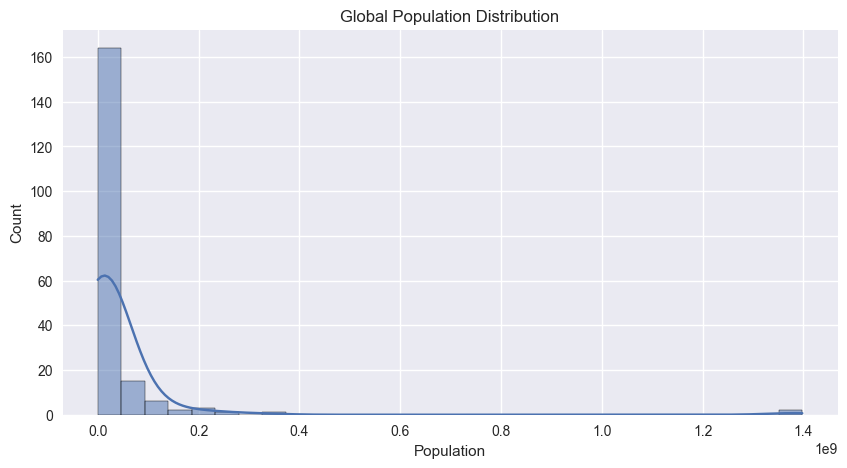

In [ ]:
# First EDA Visuals
plt.figure(figsize=(10,5))
sns.histplot(pop["Population"], bins=30, kde=True)
plt.title("Global Population Distribution")
plt.show()


In [ ]:
# AQI Category Distribution
pollution_df["PM2.5 AQI Category"].value_counts().plot(
    kind="bar", figsize=(8,4), title="PM2.5 AQI Category Distribution"
)
plt.show()

## 🔍 Initial Insights
- Population is heavily skewed toward a few highly populated countries
- Majority of AQI values fall into moderate to unhealthy categories
- Environmental stress is unevenly distributed across regions
